# Assignment No. 1 

#  Shopping Dataset Analysis & Insights

## Objective

### Perform exploratory data analysis (EDA), data cleaning, and derive meaningful insights from the combined dataset.

##  Skills & Concepts Applied

- Data Loading using Pandas  
- Data Exploration and Understanding  
- Handling Missing Values  
- Data Cleaning and Preprocessing  
- Data Type Conversion  
- Removing Duplicate Records  
- Feature Engineering  
- Exploratory Data Analysis (EDA)  
- Univariate Analysis  
- Bivariate Analysis  
- Category-Level Analysis  
- Data Visualization using Matplotlib and Seaborn  
- Statistical Summhts Generation  
- Dect Structuring  

##  Data Collection & Loading

(Importing libraries and loading dataset)


In [3]:
# Importing Libraries

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
# Loading Dataset and Understanding Its Structure

In [72]:
df = pd.read_csv("C:\\CELEBAL CEI\\AssignmentNO.1\\archive\\Combined_dataset.csv", encoding="latin1")

print(df.shape)
print(df.columns)

(1000, 24)
Index(['product_id', 'title', 'product_description', 'rating', 'ratings_count',
       'initial_price', 'discount', 'final_price', 'currency', 'images',
       'delivery_options', 'product_details', 'breadcrumbs',
       'product_specifications', 'amount_of_stars', 'what_customers_said',
       'seller_name', 'sizes', 'videos', 'seller_information', 'variations',
       'best_offer', 'more_offers', 'category'],
      dtype='object')


##  Initial Data Inspection
##### Viewing the First 5 Rows of the Dataset
##### Viewing Last 5 Rows
##### Understanding Dataset Structure and Data Types
##### Checking Missing Values in the Dataset
##### Statistical Summary of Dataset

In [1]:
#Check Data

In [214]:
print(df.head())
print(df.tail())
print(df.info())
print(df.isnull().sum())
print(df.describe())

   product_id           title                         product_description  \
0     8376765     Lino Perros              Women Navy Blue Solid Backpack   
1     9136281  Tommy Hilfiger           Unisex Navy Blue Striped Backpack   
2    17633752           Lavie              Aries Women Pink Mini Backpack   
3     1376949          F Gear  Unisex Navy & Grey Printed Burner Backpack   
4    13939916       MYTRIDENT                    Men Blue Solid Bath Robe   

   rating  ratings_count  initial_price  discount  final_price currency  \
0     3.8             15           3995      58.0       3995.0      INR   
1     4.5             67           2899      35.0       2899.0      INR   
2     4.4            226           2999      65.0       2999.0      INR   
3     4.4           1052           1675      52.0       1675.0      INR   
4     4.7             12           2899      17.0       2899.0      INR   

                                              images  ... seller_name  \
0  http://ass

##  Data Cleaning & Preprocessing

(Handling nulls, converting data types, duplicates)

### Cleaning Price Columns
### Handling Missing Data
### Removing Duplicate Records

In [15]:
#Clean Price Columns Properly

In [79]:
df['final_price'] = df['final_price'].astype(str)
df['initial_price'] = df['initial_price'].astype(str)
df['discount'] = df['discount'].astype(str)

In [81]:
df['final_price'] = df['final_price'].str.extract(r'(\d+[,\d]*\.?\d*)')[0]
df['initial_price'] = df['initial_price'].str.extract(r'(\d+[,\d]*\.?\d*)')[0]
df['discount'] = df['discount'].str.extract(r'(\d+[,\d]*\.?\d*)')[0]

In [83]:
df['final_price'] = df['final_price'].str.replace(',', '')
df['initial_price'] = df['initial_price'].str.replace(',', '')
df['discount'] = df['discount'].str.replace(',', '')

In [85]:
df['final_price'] = pd.to_numeric(df['final_price'], errors='coerce')
df['initial_price'] = pd.to_numeric(df['initial_price'], errors='coerce')
df['discount'] = pd.to_numeric(df['discount'], errors='coerce')

In [25]:
#Handling Missing Values

In [87]:
df['discount'] = df['discount'].fillna(0)

df = df.dropna(subset=['final_price', 'rating'])

In [29]:
#Remove Duplicates

In [89]:
df = df.drop_duplicates()

In [33]:
#Check Final Shape

In [91]:
print(df.shape)
print(df[['initial_price', 'final_price', 'discount']].head())

(1000, 24)
   initial_price  final_price  discount
0           3995       3995.0      58.0
1           2899       2899.0      35.0
2           2999       2999.0      65.0
3           1675       1675.0      52.0
4           2899       2899.0      17.0


##  Feature Engineering

#### Creating Price Difference Feature

#### Building Popularity Score Metric



In [3]:
#Feature Engineering
#Create Price Difference

In [93]:
df['price_difference'] = df['initial_price'] - df['final_price']

print(df[['initial_price', 'final_price', 'price_difference']].head())

   initial_price  final_price  price_difference
0           3995       3995.0               0.0
1           2899       2899.0               0.0
2           2999       2999.0               0.0
3           1675       1675.0               0.0
4           2899       2899.0               0.0


In [52]:
#creating Popularity Metric

In [95]:
df['popularity'] = df['rating'] * df['ratings_count']

print(df[['rating', 'ratings_count', 'popularity']].head())

   rating  ratings_count  popularity
0     3.8             15        57.0
1     4.5             67       301.5
2     4.4            226       994.4
3     4.4           1052      4628.8
4     4.7             12        56.4


###  Univariate Analysis

##### Final Price Distribution
##### Rating Distribution
##### Discount Distribution

In [47]:
#Univariate Analysis
#Final Price Distribution

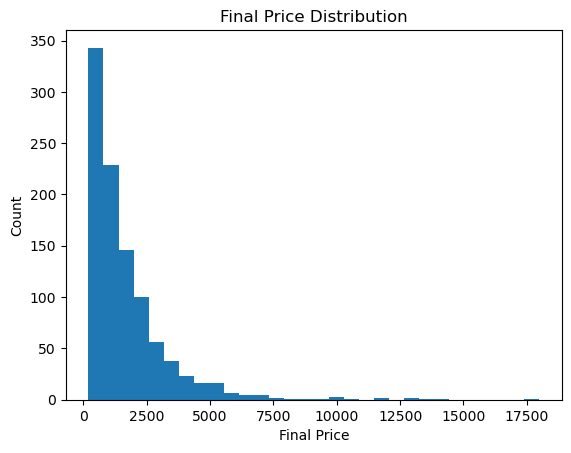

In [97]:
plt.hist(df['final_price'], bins=30)
plt.title("Final Price Distribution")
plt.xlabel("Final Price")
plt.ylabel("Count")
plt.show()

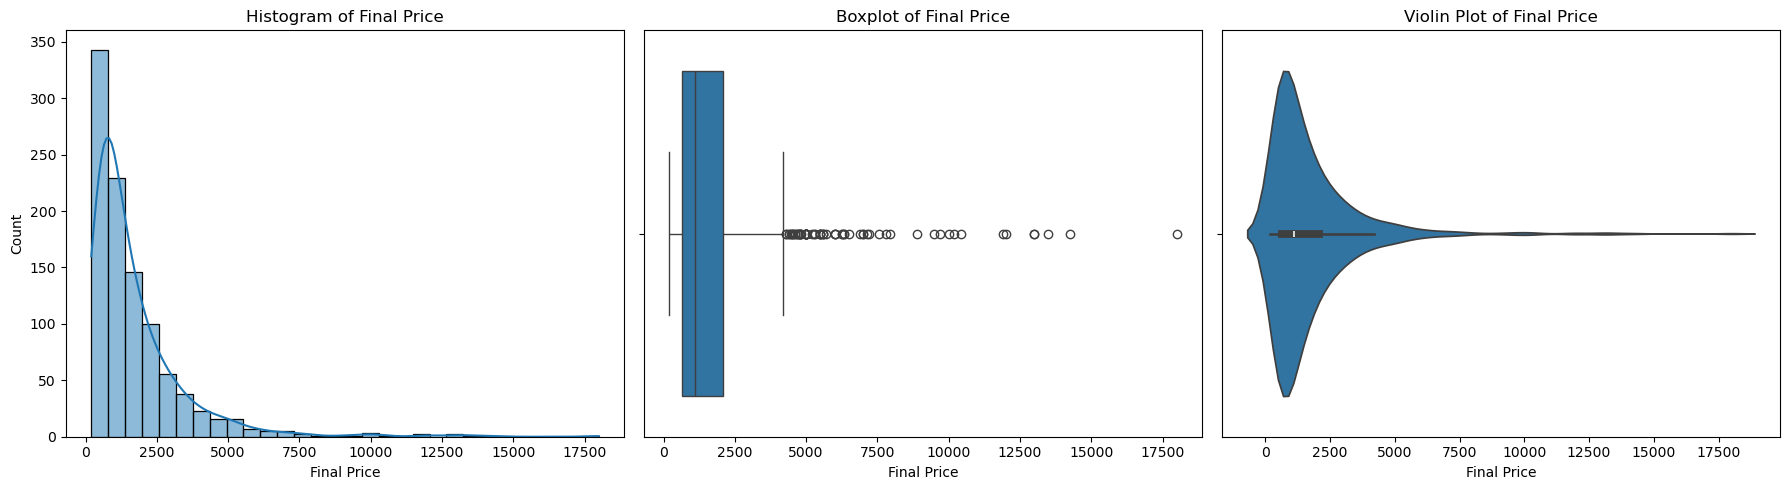

In [99]:
plt.figure(figsize=(18, 5))

# 1. Histogram + KDE
plt.subplot(1, 3, 1)
sns.histplot(df['final_price'], bins=30, kde=True)
plt.title("Histogram of Final Price")
plt.xlabel("Final Price")
plt.ylabel("Count")

# 2. Boxplot
plt.subplot(1, 3, 2)
sns.boxplot(x=df['final_price'])
plt.title("Boxplot of Final Price")
plt.xlabel("Final Price")

# 3. Violin Plot
plt.subplot(1, 3, 3)
sns.violinplot(x=df['final_price'])
plt.title("Violin Plot of Final Price")
plt.xlabel("Final Price")

plt.tight_layout()
plt.show()

In [51]:
#Rating Distribution

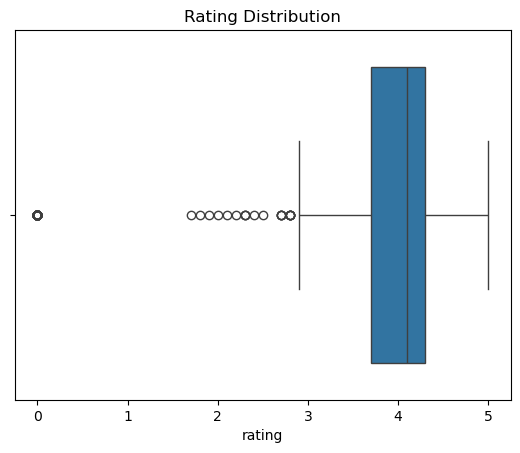

In [101]:
sns.boxplot(x=df['rating'])
plt.title("Rating Distribution")
plt.show()

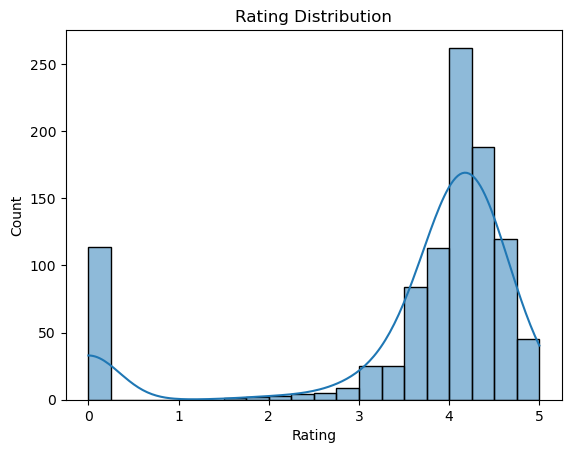

In [103]:
sns.histplot(df['rating'], bins=20, kde=True)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [105]:
#Discount Distribution

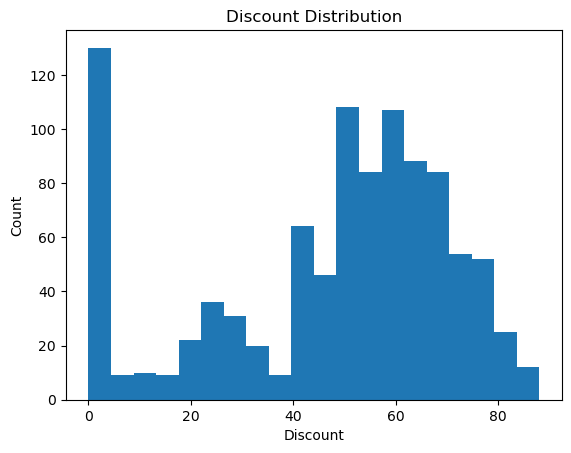

In [107]:
plt.hist(df['discount'], bins=20)
plt.title("Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Count")
plt.show()

###  Bivariate Analysis

In [110]:
#Bivariate Analysis

In [112]:
#1.Price vs Rating
# 2. Discount vs Ratings Count
# 3. Initial Price vs Final Price

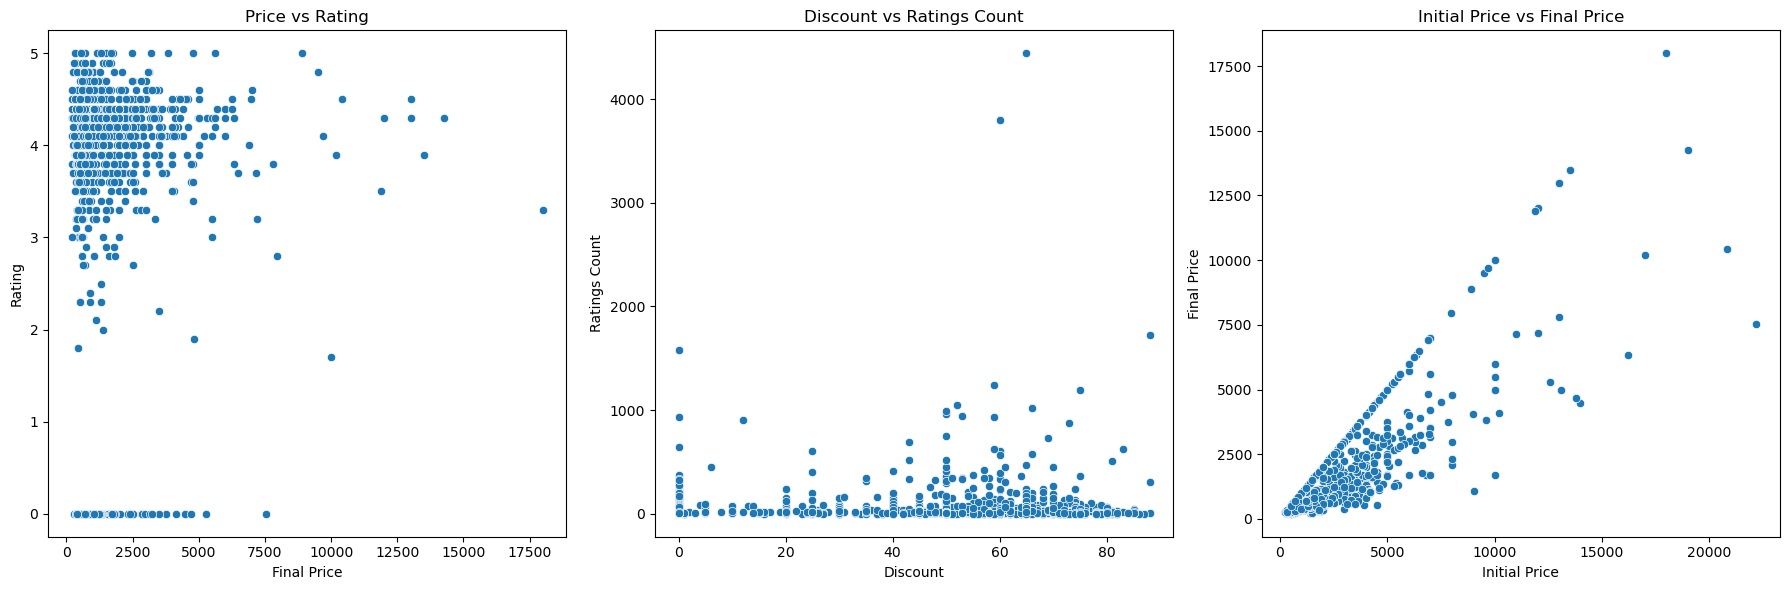

In [114]:
plt.figure(figsize=(18, 6))

# 1. Price vs Rating
plt.subplot(1, 3, 1)
sns.scatterplot(x='final_price', y='rating', data=df)
plt.title("Price vs Rating")
plt.xlabel("Final Price")
plt.ylabel("Rating")

# 2. Discount vs Ratings Count
plt.subplot(1, 3, 2)
sns.scatterplot(x='discount', y='ratings_count', data=df)
plt.title("Discount vs Ratings Count")
plt.xlabel("Discount")
plt.ylabel("Ratings Count")

# 3. Initial Price vs Final Price
plt.subplot(1, 3, 3)
sns.scatterplot(x='initial_price', y='final_price', data=df)
plt.title("Initial Price vs Final Price")
plt.xlabel("Initial Price")
plt.ylabel("Final Price")

plt.tight_layout()
plt.show()

In [116]:
#Discount vs Ratings Count

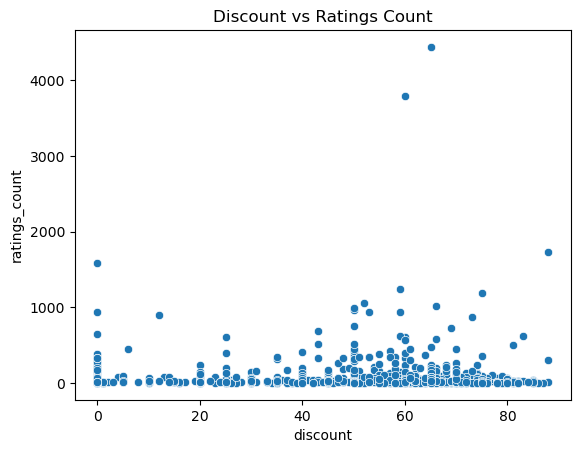

In [118]:
sns.scatterplot(x='discount', y='ratings_count', data=df)
plt.title("Discount vs Ratings Count")
plt.show()

In [120]:
#Price vs Popularity

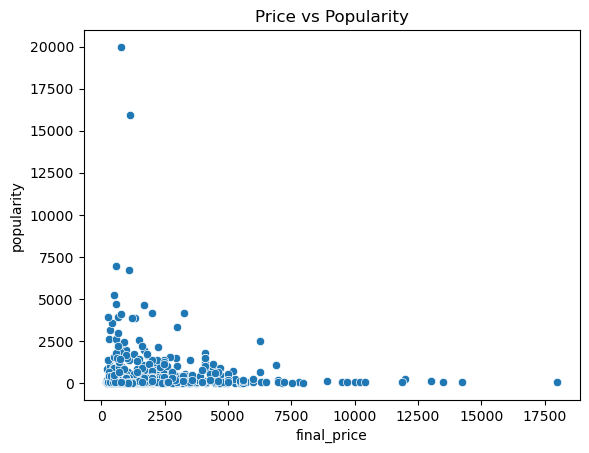

In [122]:
sns.scatterplot(x='final_price', y='popularity', data=df)
plt.title("Price vs Popularity")
plt.show()

###  Category-Level Performance Analysis

In [125]:
#Category-Level Analysis

In [127]:
#Average Price by Category

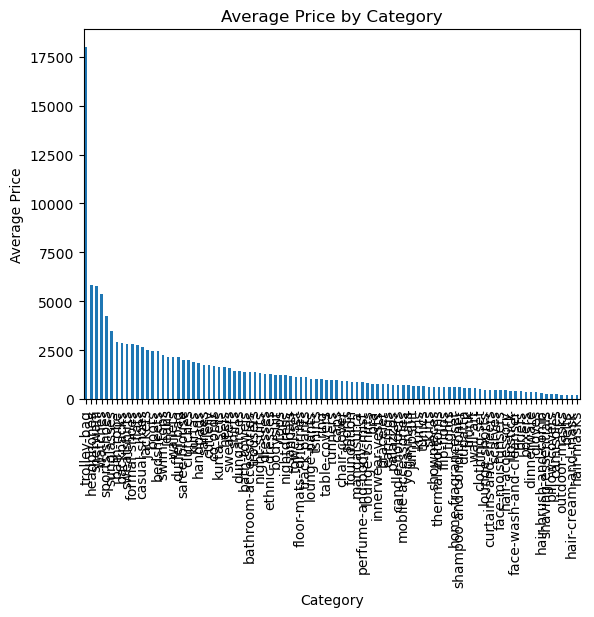

In [129]:
category_price = df.groupby('category')['final_price'].mean().sort_values(ascending=False)

category_price.plot(kind='bar')
plt.title("Average Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price")
plt.show()

In [131]:
#Average Price by Category (Top 10)

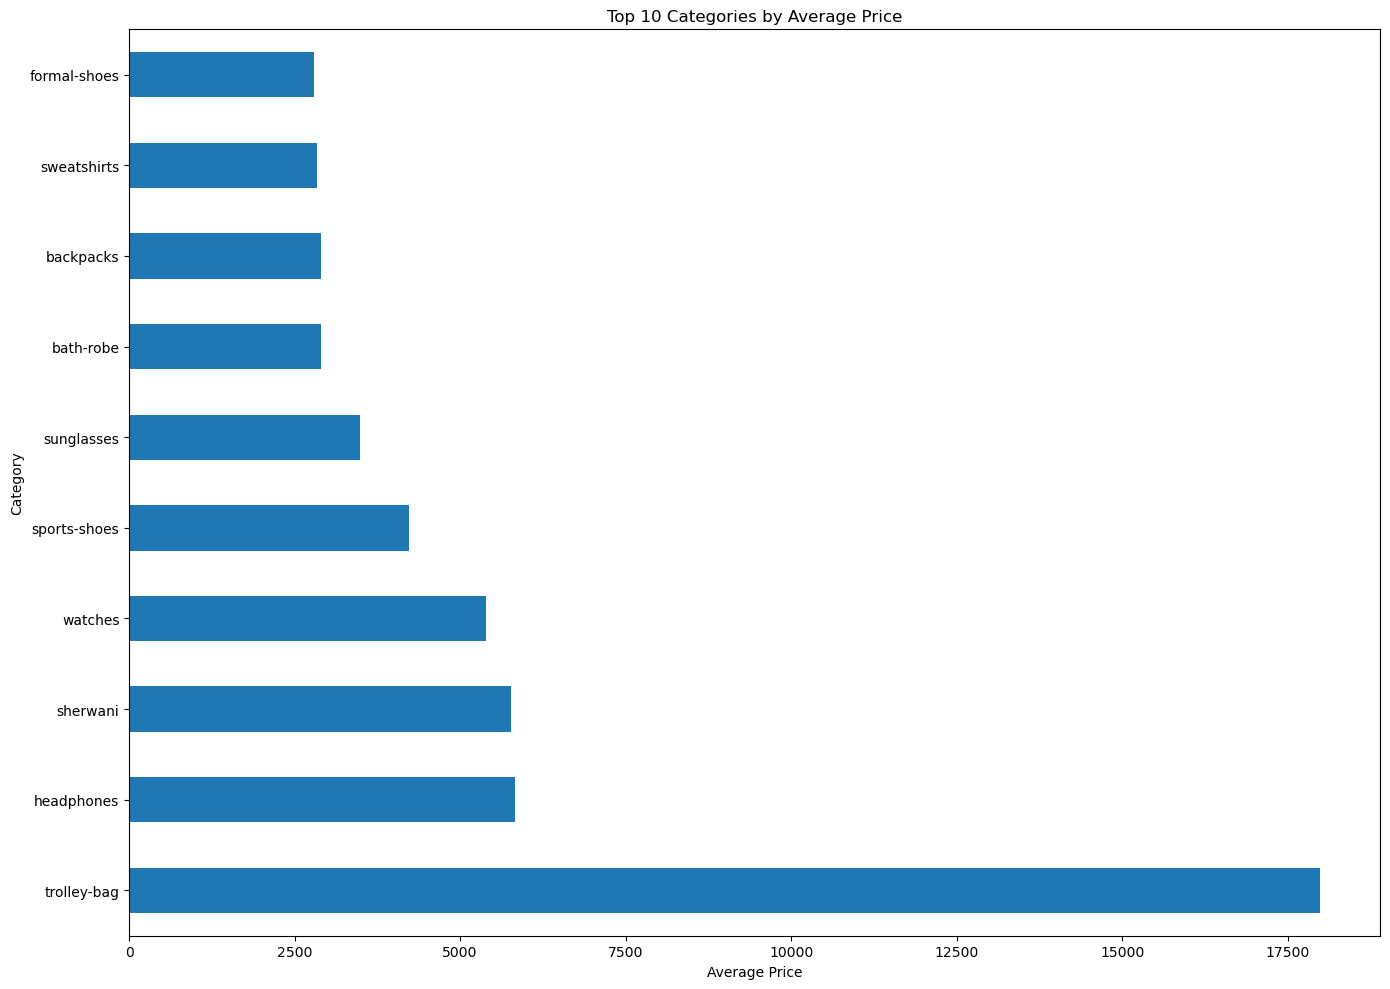

In [133]:
category_price = df.groupby('category')['final_price'].mean().sort_values(ascending=False)

plt.figure(figsize=(14,10))
category_price.head(10).plot(kind='barh')

plt.title("Top 10 Categories by Average Price")
plt.xlabel("Average Price")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [135]:
#Average Rating by Category(Top10)

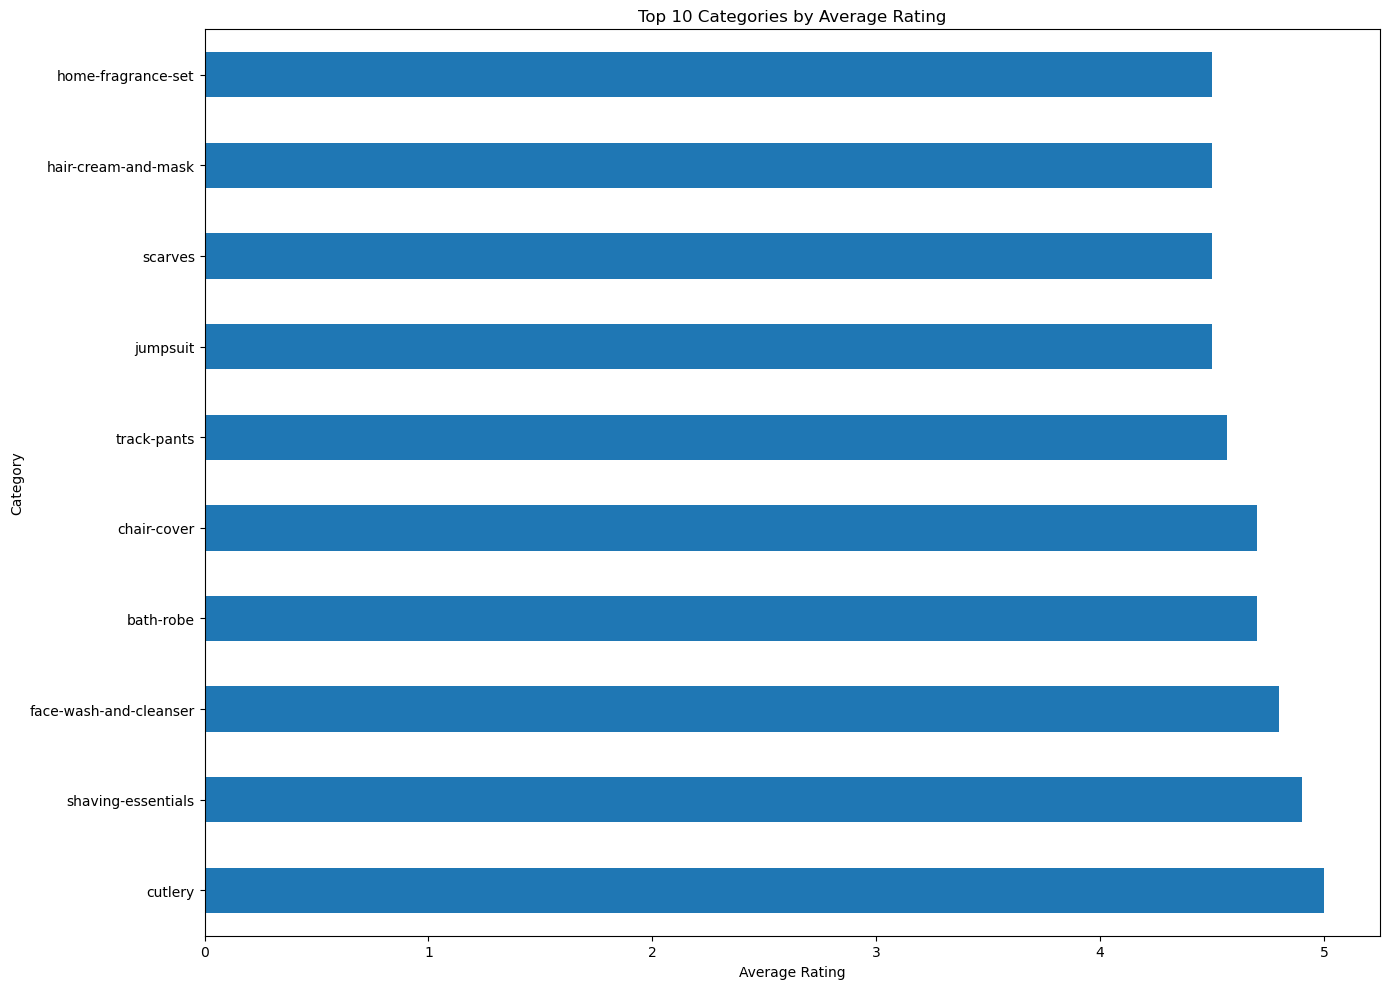

In [137]:
category_rating = df.groupby('category')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(14,10))
category_rating.head(10).plot(kind='barh')   # top 10 + horizontal

plt.title("Top 10 Categories by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [139]:
#Top Categories by Popularity

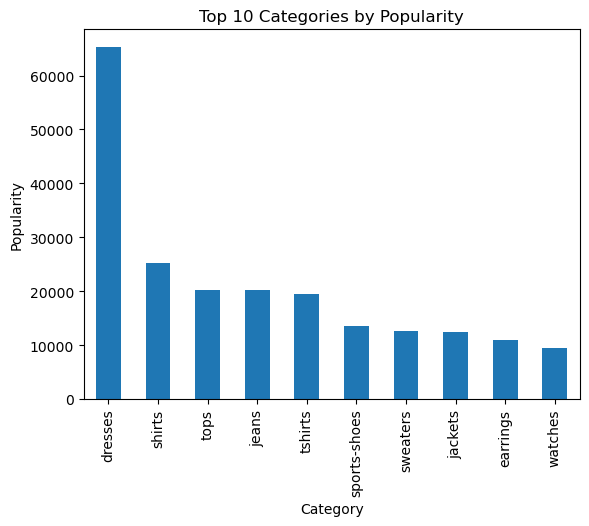

In [141]:
top_categories = df.groupby('category')['popularity'].sum().sort_values(ascending=False).head(10)

top_categories.plot(kind='bar')
plt.title("Top 10 Categories by Popularity")
plt.xlabel("Category")
plt.ylabel("Popularity")
plt.show()

In [143]:
#Category share by total ratings count

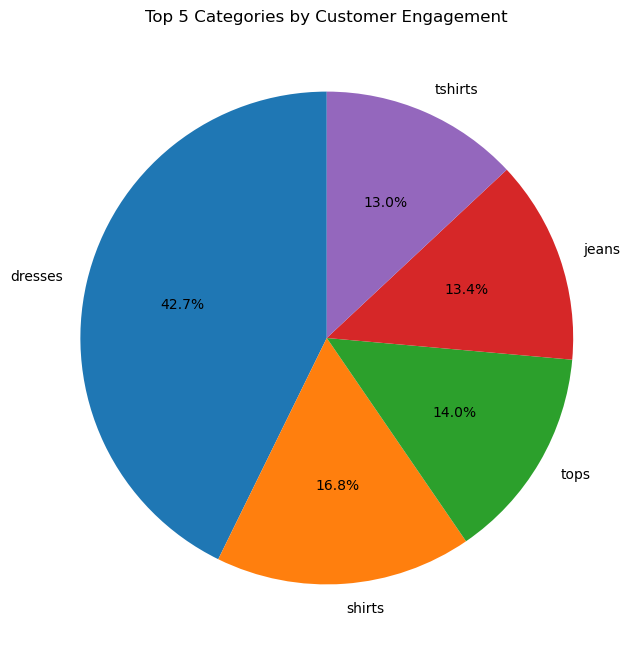

In [145]:
category_share = df.groupby('category')['ratings_count'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,8))
plt.pie(
    category_share,
    labels=category_share.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Top 5 Categories by Customer Engagement")
plt.show()

## Key Findings & Insights

In [148]:
#Top Products

In [150]:
#Top Rated Products

In [152]:
top_products = df.sort_values(by='rating', ascending=False)[
    ['title', 'category', 'rating', 'final_price']
].head(10)

print(top_products)

              title      category  rating  final_price
658           ASICS        shorts     5.0       1149.0
437        VASTRADO        kurtas     5.0        539.0
178          DOOR74       dresses     5.0        719.0
721            Puma  sports-shoes     5.0       5599.0
88       ellementry       cutlery     5.0       1750.0
22       London Rag         boots     5.0       3839.0
917  Bannos Swagger   track-pants     5.0       1699.0
52      Bruchi CLUB        briefs     5.0        310.0
881           MANGO          tops     5.0       2490.0
996           GUESS       watches     5.0       8900.0


In [154]:
#Most Popular Products

In [156]:
popular_products = df.sort_values(by='popularity', ascending=False)[
    ['title', 'category', 'popularity']
].head(10)

print(popular_products)

            title     category  popularity
143     SASSAFRAS      dresses     19984.5
117        Athena      dresses     15947.4
24         Jockey          bra      6960.8
21        Mactree        boots      6735.3
582    HIGHLANDER       shirts      5233.2
538        KALINI       sarees      4656.6
3          F Gear    backpacks      4628.8
991  Daniel Klein      watches      4136.0
773      Roadster  sweatshirts      4123.7
944      Roadster      tshirts      4075.4


In [158]:
#Final Insights

In [160]:
print("Total Products:", len(df))
print("Average Rating:", df['rating'].mean())
print("Average Final Price:", df['final_price'].mean())
print("Most Expensive Category:")
print(category_price.head(1))
print("Highest Rated Category:")
print(category_rating.head(1))
print("Most Popular Category:")
print(top_categories.head(1))

Total Products: 1000
Average Rating: 3.6215
Average Final Price: 1706.096
Most Expensive Category:
category
trolley-bag    17995.0
Name: final_price, dtype: float64
Highest Rated Category:
category
cutlery    5.0
Name: rating, dtype: float64
Most Popular Category:
category
dresses    65305.1
Name: popularity, dtype: float64


In [162]:
#Filter Operations

In [164]:
high_rated = df[df['rating'] > 4]

print(high_rated[['title', 'rating', 'final_price']].head())

            title  rating  final_price
1  Tommy Hilfiger     4.5       2899.0
2           Lavie     4.4       2999.0
3          F Gear     4.4       1675.0
4       MYTRIDENT     4.7       2899.0
5             H&M     4.5       1399.0


In [166]:
#Products with Discount Greater than 50%

In [168]:
high_discount = df[df['discount'] > 50]

print(high_discount[['title', 'discount', 'final_price']].head())

         title  discount  final_price
0  Lino Perros      58.0       3995.0
2        Lavie      65.0       2999.0
3       F Gear      52.0       1675.0
6   AVI Living      65.0       1399.0
7      My Room      54.0       2999.0


In [170]:
#Products in a Specific Category

In [172]:
backpacks = df[df['category'] == 'backpacks']

print(backpacks.head())

   product_id           title                         product_description  \
0     8376765     Lino Perros              Women Navy Blue Solid Backpack   
1     9136281  Tommy Hilfiger           Unisex Navy Blue Striped Backpack   
2    17633752           Lavie              Aries Women Pink Mini Backpack   
3     1376949          F Gear  Unisex Navy & Grey Printed Burner Backpack   

   rating  ratings_count  initial_price  discount  final_price currency  \
0     3.8             15           3995      58.0       3995.0      INR   
1     4.5             67           2899      35.0       2899.0      INR   
2     4.4            226           2999      65.0       2999.0      INR   
3     4.4           1052           1675      52.0       1675.0      INR   

                                              images  ... seller_name  \
0  http://assets.myntassets.com/assets/images/837...  ...         NaN   
1  http://assets.myntassets.com/assets/images/913...  ...         NaN   
2  http://assets.my

In [174]:
#Sorting Operations
#Sort by Highest Price

In [176]:
highest_price = df.sort_values(by='final_price', ascending=False)

print(highest_price[['title', 'final_price']].head(10))

            title  final_price
920  Nasher Miles      17995.0
724        ADIDAS      14249.0
692  UNDER ARMOUR      13499.0
714        ADIDAS      12999.0
702          Puma      12999.0
704          Puma      11999.0
995         KREDO      11890.0
985          MVMT      10416.0
716        ADIDAS      10199.0
332    CrossBeats       9999.0


In [178]:
#Sort by Highest Ratings Count

In [180]:
most_reviewed = df.sort_values(by='ratings_count', ascending=False)

print(most_reviewed[['title', 'ratings_count']].head(10))

          title  ratings_count
143   SASSAFRAS           4441
117      Athena           3797
21      Mactree           1727
24       Jockey           1582
582  HIGHLANDER           1246
538      KALINI           1194
3        F Gear           1052
119         U&F           1023
944    Roadster            994
773    Roadster            959


In [182]:
#Grouping Operations

In [184]:
#Average Price by Seller

In [186]:
seller_price = df.groupby('seller_name')['final_price'].mean().sort_values(ascending=False)

print(seller_price.head(10))

seller_name
SELâââITEâââGITâââââââââ                                  9999.000000
LSDâââFESâââES âââââââââIMIââââââ             7799.000000
Netâââstrâââtioâââââââââs Pâââââââââ    7156.666667
PumâââporâââIndâââââââââtd.âââââââââ    6461.500000
KisâââAppâââls âââââââââimiââââââ             5764.600000
CLAâââ REâââNCEâââââââââ PVââââââ             5499.000000
V Râââil âââ Ltâââ                                                    4999.000000
Dazâââ Exâââts                                                              4479.000000
TEAâââOD                                                                          4079.000000
Plaâââum âââhioâââ                                                    

In [188]:
#Total Products by Category

In [190]:
category_count = df['category'].value_counts()

print(category_count)

category
tops                  122
dresses               100
shirts                 97
jeans                  57
sports-shoes           51
                     ... 
lounge-pants            1
lounge-shorts           1
mangalsutra             1
mobile-accessories      1
yoga-mats               1
Name: count, Length: 97, dtype: int64


In [192]:
#Correlation Analysis


In [194]:
correlation = df[['rating', 'ratings_count', 'initial_price', 'discount', 'final_price', 'popularity']].corr()

print(correlation)

                 rating  ratings_count  initial_price  discount  final_price  \
rating         1.000000       0.125795      -0.081486 -0.184076     0.084587   
ratings_count  0.125795       1.000000      -0.023120  0.008053    -0.030233   
initial_price -0.081486      -0.023120       1.000000  0.055446     0.819315   
discount      -0.184076       0.008053       0.055446  1.000000    -0.202756   
final_price    0.084587      -0.030233       0.819315 -0.202756     1.000000   
popularity     0.126187       0.998680      -0.022836  0.006366    -0.028656   

               popularity  
rating           0.126187  
ratings_count    0.998680  
initial_price   -0.022836  
discount         0.006366  
final_price     -0.028656  
popularity       1.000000  


In [196]:
#Heatmap

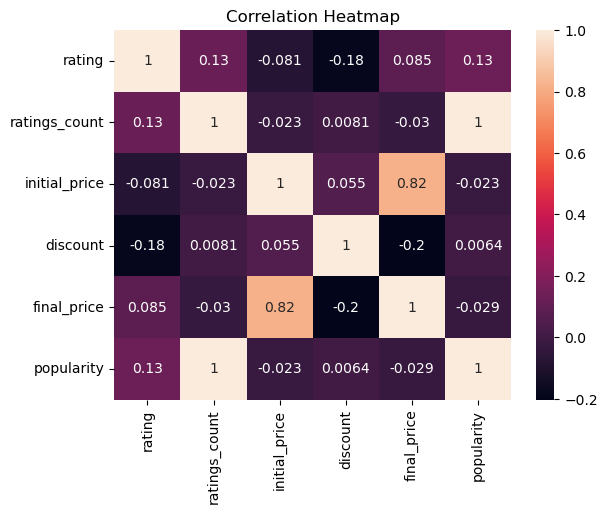

In [198]:
sns.heatmap(correlation, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [200]:
#Outlier Detection
#Boxplot for Final Price

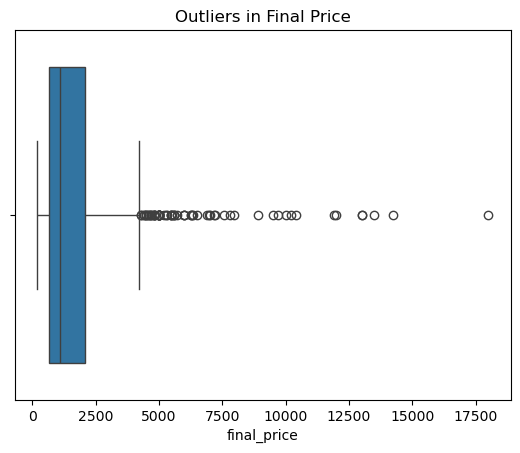

In [202]:
sns.boxplot(x=df['final_price'])
plt.title("Outliers in Final Price")
plt.show()

In [204]:
#Seller Analysis

#Top Sellers by Number of Products

In [206]:
top_sellers = df['seller_name'].value_counts().head(10)

print(top_sellers)

seller_name
Supâââom âââ                                                       40
Visâââ Stâââ                                                       29
Flaâââtarâââmmeââââââ                                  27
ARVâââ LIâââTYLâââââââââLIMââââââ    26
Wesâââry âââdinâââââââââd_Mââââââ    21
Truââât Câââercâââ                                           16
Truâââm Râââil                                                     15
INDâââ NEâââE PâââââââââMITâââ             13
RetâââNetâââ                                                       12
AARâââLIFâââYLEâââââââââLIMââââââ    12
Name: count, dtype: int64


##  Exporting Cleaned Dataset

In [153]:
#Save Cleaned Dataset

In [155]:
df.to_csv("cleaned_shopping_dataset.csv", index=False)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully
